# Part 4: Hybrid Recommendation System & Evaluation
In previous notebook, two systems independent recommendation:
* **Content-Based Filtering:** Recommend based on genres of movies. Very good to solve **Cold Start** problem but easy to meet **Circular Recommendation** problem
* **Collaborative Filtering (Item-Item):** Recommend based on group behaviour. Recommend many types of movies and understanding "Hidden preferences"

**Goal of this notebook:** Build a Hybrid system to combine the power of two models above

In [5]:
%load_ext autoreload
%autoreload 2

## Import libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import joblib

import sys
sys.path.append('..')
from src.utils import load_movie_mapping,get_items_rated_by_user,get_movie_title_by_id
from src.recommender import ContentBasedFiltering, NBCF

## 1.Load data and pre-train models

### 1.1.Train-test data

In [15]:
ratings_train=pd.read_csv('../data/processed/ratings_a_train.csv',header=0).values
ratings_train

array([[        0,         0,         5, 874965758],
       [        0,         1,         3, 876893171],
       [        0,         2,         4, 878542960],
       ...,
       [      942,      1187,         3, 888640250],
       [      942,      1227,         3, 888640275],
       [      942,      1329,         3, 888692465]], shape=(90570, 4))

In [16]:
ratings_test=pd.read_csv('../data/processed/ratings_a_test.csv',header=0).values
ratings_test

array([[        0,        19,         4, 887431883],
       [        0,        32,         4, 878542699],
       [        0,        60,         4, 878542420],
       ...,
       [      942,       569,         1, 888640125],
       [      942,       807,         4, 888639868],
       [      942,      1066,         2, 875501756]], shape=(9430, 4))

### 1.2.Load models

**Content-Based model**

In [8]:
cb_model=joblib.load('../models/cb_model.pkl')

In [9]:
cb_model

**Collaborative Filtering (Item-Item) model**

In [10]:
cf_model=joblib.load('../models/cf_model.pkl')

## 2.Build Hybrid System

We will encapsulate hybrid logic in a class, use function:

$$\hat{y}_{hybrid}=\alpha \cdot \hat{y}_{cb}+(1-\alpha) \cdot \hat{y}_{cf}$$

**Where:**
* $\alpha \in [0,1]$

In [18]:
class HybridRecommender:
    def __init__(self,cb_model,cf_model,alpha=0.5):
        self.cb_model=cb_model
        self.cf_model=cf_model
        self.alpha=alpha
    def predict_test(self,test):
        cf_predict=self.cf_model.predict_test(test)
        n_tests=test.shape[0]
        cb_predict=np.zeros(n_tests)
        for idx in range(n_tests):
            u=test[idx,0]
            i=test[idx,1]
            cb_predict[idx]=self.cb_model.Yhat[i,u]
        return self.alpha*cb_predict+(1-self.alpha)*cf_predict
    def fit(self,ratings_data):
        self.ratings_data=ratings_data
    def recommend_for_user(self,user_id,top=10):
        rated_items,_=get_items_rated_by_user(self.ratings_data,user_id)
        rated_items=rated_items.tolist()
        
        n_items=self.cb_model.Yhat.shape[0]
        hybrid_scores=np.zeros(n_items)
        cb_scores=self.cb_model.Yhat[:,user_id]
        for i in range(n_items):
            if i in rated_items:
                hybrid_scores[i]=-1e9
            else:
                cf_score=self.cf_model.predict(user_id,i,normalized=0)
                cb_score=cb_scores[i]
                hybrid_scores[i]=self.alpha*cb_score+(1-self.alpha)*cf_score
        recommend_items=np.argsort(hybrid_scores)[-top:][::-1]
        return recommend_items
    def RMSE(self,ratings_data,prediction):
        y_true=ratings_data[:,2]
        return np.sqrt(mean_squared_error(y_true,prediction))  

## 3.Hyperparameter tunning: Finding the optimal $\alpha$

In [20]:
alphas=np.arange(0.0,1.1,0.1)
rmses=[]

for alpha in alphas:
    hybrid_system=HybridRecommender(cb_model,cf_model,alpha)
    hybrid_system.fit(ratings_train)
    prediction=hybrid_system.predict_test(ratings_test)
    rmse=hybrid_system.RMSE(ratings_test,prediction)
    rmses.append(rmse)
    print(f'Alpha: {alpha}, RMSE: {rmse}')

Alpha: 0.0, RMSE: 0.7061878880640974
Alpha: 0.1, RMSE: 0.7220083467079217
Alpha: 0.2, RMSE: 0.7423839449310422
Alpha: 0.30000000000000004, RMSE: 0.7669517195852953
Alpha: 0.4, RMSE: 0.7953232727427886
Alpha: 0.5, RMSE: 0.827107263700273
Alpha: 0.6000000000000001, RMSE: 0.861926268698895
Alpha: 0.7000000000000001, RMSE: 0.8994278788144389
Alpha: 0.8, RMSE: 0.9392908363292364
Alpha: 0.9, RMSE: 0.9812273899272815
Alpha: 1.0, RMSE: 1.0249830514613054


**Find best alpha**

In [21]:
best_alpha=alphas[np.argmin(rmses)]
best_rmse=np.min(rmses)
print(f'Best alpha: {best_alpha}, Best RMSE: {best_rmse}')

Best alpha: 0.0, Best RMSE: 0.7061878880640974


## 4.Evaluation and Visualization

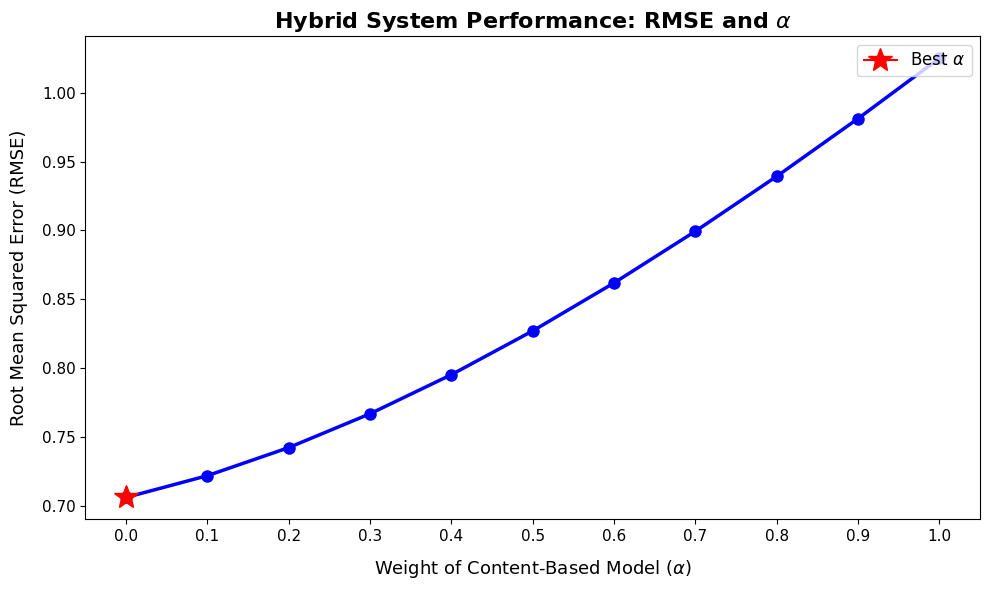

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, rmses, marker='o', linestyle='-', color='blue', linewidth=2.5, markersize=8)
plt.plot(best_alpha, best_rmse, marker='*', markersize=18, color='red',label='Best $\\alpha$')
plt.title('Hybrid System Performance: RMSE and $\\alpha$', fontsize=16, fontweight='bold')
plt.xlabel('Weight of Content-Based Model ($\\alpha$)', fontsize=13, labelpad=10)
plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=13, labelpad=10)
plt.xticks(alphas, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

## 5.Recommend

In [29]:
model=HybridRecommender(cb_model,cf_model,0.1)
model.fit(ratings_test)

In [30]:
movie_mapping=load_movie_mapping()
movie_mapping

,movie id,movie title
0,0,Toy Story (1995)
1,1,GoldenEye (1995)
2,2,Four Rooms (1995)
3,3,Get Shorty (1995)
4,4,Copycat (1995)
...,...,...
1677,1677,Mat' i syn (1997)
1678,1678,B. Monkey (1998)
1679,1679,Sliding Doors (1998)
1680,1680,You So Crazy (1994)


In [32]:
recommend_movies_indices=model.recommend_for_user(0) ## user 1
for index in recommend_movies_indices:
    print(f'Movie ID: {index+1}, Title: {get_movie_title_by_id(movie_mapping,index)}')

Movie ID: 1653, Title: Entertaining Angels: The Dorothy Day Story (1996)
Movie ID: 1467, Title: Saint of Fort Washington, The (1993)
Movie ID: 1599, Title: Someone Else's America (1995)
Movie ID: 1189, Title: Prefontaine (1997)
Movie ID: 1536, Title: Aiqing wansui (1994)
Movie ID: 1201, Title: Marlene Dietrich: Shadow and Light (1996) 
Movie ID: 814, Title: Great Day in Harlem, A (1994)
Movie ID: 1617, Title: Hugo Pool (1997)
Movie ID: 1122, Title: They Made Me a Criminal (1939)
Movie ID: 1500, Title: Santa with Muscles (1996)


### Save model

In [33]:
joblib.dump(model,'../models/hb_model.pkl')

['../models/hb_model.pkl']